# Introduction

**Definition:**  
PSO is a meta-heuristic algorithm designed to optimize complex functions by mimicking the collective intelligence of social animals, such as birds or fish.

**Inspiration:**  
Draws from the cooperative behavior of flocks of birds or schools of fish, where individuals share information to benefit the group.

**Purpose:**  
Used to find the global optimum (maximum or minimum) of a fitness function in complex, multidimensional search spaces.

**Key Characteristics:**
- Does not rely on gradient information, making it suitable for **non-differentiable**, **nonlinear**, or **complex** problems.
- Combines individual effort (**personal best**) and communal insight (**global best**) to guide particles toward optimal solutions.

# Core Concepts of PSO

**Swarm and Particles:**
- PSO involves a **swarm** of particles, each representing a potential solution to an optimization problem.
- Each particle has:
    - **Position:** A candidate solution in the search space.
    - **Velocity:** Determines the direction and speed of movement.
    - **Fitness Value:** Measures the quality of the solution based on the fitness function.

**Movement Dynamics:**
- Particles adjust their positions by updating their velocities based on:

    - **Personal Best ($p_{best}$):** The best position the particle has encountered.

    - **Global Best ($g_{best}$):** The best position found by any particle in the swarm.
    
- The swarm collectively moves toward areas of the search space with better fitness values, guided by these best positions.

**Algorithm Workflow:**
- **Initialization:** Randomly assign initial positions and velocities to particles.

- **Fitness Evaluation:** Calculate the fitness value of each particle's position.

- **Update Personal and Global Bests:**
    - Update $p_{best}$ if the current position yields a better fitness value.
    - Update $g_{best}$ if any particle's position is better than the current global best.

# Velocity and Position Update:

- Adjust each particle's velocity using a formula that balances:

    - **Inertia** (previous velocity).

    - **Cognitive component** (attraction to $p_{best}$).

    - **Social component** (attraction to $g_{best}$).
    
- Update the particle's position based on the new velocity.

**Mathematically**

- **Velocity Update:**
    $$v_i^{k+1} = \underbrace{w v_i^k}_{\text{interia}} + \underbrace{c_1  r_1 ({p_{best_i}}^k − x_i^k)}_{\text{personal best}} + \underbrace{c2 r2 (g_{best_l} − x_i^k)}_{\text{social (swarm) best}}$$

- **Position Update:**
    $$x_i^{k+1} = x_i^k + v_i^{k+1}$$

# Flowchart

<div style="text-align:center">
    <img src="./assets/pco_flowchart.png" alt="flowchart for PCO algorithm">
</div>

# Pseudocode

**Algorithm: Particle Swarm Optimization**

**Input:**
- Objective function $f(x)$
- Swarm size $N$
- Max iterations $T$  

**Output:**
- Global best position $g_{best}$ 

> 1. Initialize swarm:  
>&nbsp;&nbsp;&nbsp;&nbsp;- Random positions $x_i$ for $i = 1 to N$  
>&nbsp;&nbsp;&nbsp;&nbsp;- Random velocities $v_i$ for $i = 1 to N$  
>&nbsp;&nbsp;&nbsp;&nbsp;- $p_{best_i} = $x_i$ for $i = 1 to N$$  
>&nbsp;&nbsp;&nbsp;&nbsp;- $g_{best} = argmin(f(p_best_i))$  
> 2. For $t = 1$ to T:  
>&nbsp;&nbsp;&nbsp;&nbsp;For $i = 1$ to $N$:  
>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;a. Update velocity: $v_i = w*v_i + c1*r1*(p_best_i - x_i) + c2*r2*(g_best - x_i)$  
>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;b. Update position: $x_i = x_i + v_i$  
>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;c. Evaluate fitness: $f_i = f(x_i)$  
>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;d. Update personal best: if $f_i < f(p_best_i) then p_best_i = x_i$  
>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;e. Update global best: if $f_i < f(g_best)$ then $g_best = x_i$  
> 3. Return $g_best$

# Parameter Analysis

1. **Inertia Weight (w):**
   - Controls the balance between exploration and exploitation
   - High values (0.9-1.2): More exploration
   - Low values (0.4-0.6): More exploitation
   - Adaptive strategies: Start high, decrease over time

2. **Cognitive Coefficient (c1):**
   - Controls attraction to personal best
   - Typical range: 1.5-2.5
   - Higher values: More individualistic behavior

3. **Social Coefficient (c2):**
   - Controls attraction to global best
   - Typical range: 1.5-2.5
   - Higher values: More collective behavior

4. **Swarm Size:**
   - Small (10-30): Faster convergence, may get stuck in local optima
   - Large (50-100): Better exploration, slower convergence

# Codes

## Simple Implementation

In [1]:
import numpy as np
import numpy.random as rnd
import matplotlib.pyplot as plt

POP_SIZE = 10 #population size 
MAX_ITER = 30 #the amount of optimization iterations
w = 0.2 #inertia weight
c1 = 1 #personal acceleration factor
c2 = 2 #social acceleration factor

def populate(size):
  x1,x2 = -10, 3 #x1, x2 = right and left boundaries of our X axis
  pop = rnd.uniform(x1,x2, size) # size = amount of particles in population
  return pop

particles = populate(POP_SIZE) #generating a set of particles
velocities = np.zeros(np.shape(particles)) #velocities of the particles
# gains = -np.array(function(particles)) #calculating function values for the population
gains = -np.array(particles) #calculating function values for the population

best_positions = np.copy(particles) #it's our first iteration, so all positions are the best
swarm_best_position = particles[np.argmax(gains)] #x with with the highest gain
swarm_best_gain = np.max(gains) #highest gain

l = np.empty((MAX_ITER, POP_SIZE)) #array to collect all pops to visualize afterwards

for i in range(MAX_ITER):

    l[i] = np.array(np.copy(particles)) #collecting a pop to visualize

    r1 = rnd.uniform(0, 1, POP_SIZE) #defining a random coefficient for personal behavior
    r2 = rnd.uniform(0, 1, POP_SIZE) #defining a random coefficient for social behavior
    
    velocities = np.array(w * velocities + c1 * r1 * (best_positions - particles) + c2 * r2 * (swarm_best_position - particles)) #calculating velocities

    particles+=velocities #updating position by adding the velocity

    # new_gains = -np.array(function(particles)) #calculating new gains
    new_gains = -np.array(particles) #calculating new gains

    idx = np.where(new_gains > gains) #getting index of Xs, which have a greater gain now
    best_positions[idx] = particles[idx] #updating the best positions with the new particles
    gains[idx] = new_gains[idx] #updating gains

    if np.max(new_gains) > swarm_best_gain: #if current maxima is greateer than across all previous iters, than assign
        swarm_best_position = particles[np.argmax(new_gains)] #assigning the best candidate solution
        swarm_best_gain = np.max(new_gains) #assigning the best gain

    print(f'Iteration {i+1} \tGain: {swarm_best_gain}')

Iteration 1 	Gain: 17.28175128854286
Iteration 2 	Gain: 23.965907032335473
Iteration 3 	Gain: 37.603646657308126
Iteration 4 	Gain: 57.284208296471974
Iteration 5 	Gain: 79.28167613651337
Iteration 6 	Gain: 97.05580161290992
Iteration 7 	Gain: 122.58910818515233
Iteration 8 	Gain: 161.12768337585925
Iteration 9 	Gain: 197.21363174285457
Iteration 10 	Gain: 242.40898696929958
Iteration 11 	Gain: 275.1108953732066
Iteration 12 	Gain: 325.36687602380357
Iteration 13 	Gain: 359.0665263279799
Iteration 14 	Gain: 390.8633505601524
Iteration 15 	Gain: 416.65915315197077
Iteration 16 	Gain: 450.9006268052125
Iteration 17 	Gain: 477.14611679836503
Iteration 18 	Gain: 531.8282196473006
Iteration 19 	Gain: 575.5343786379925
Iteration 20 	Gain: 616.3446886523654
Iteration 21 	Gain: 676.2851469493947
Iteration 22 	Gain: 724.9590348581519
Iteration 23 	Gain: 758.8690563293272
Iteration 24 	Gain: 778.4135958824663
Iteration 25 	Gain: 930.1116936902931
Iteration 26 	Gain: 1081.6021990928114
Iteration 

## Enhanced Class-Based Implementation

=== Sphere Function ===
Iteration 0: Best fitness = 0.141616
Iteration 20: Best fitness = 0.000065
Iteration 40: Best fitness = 0.000001
Iteration 60: Best fitness = 0.000000
Iteration 80: Best fitness = 0.000000
Best position: [ 8.95931107e-07 -3.29052841e-07  1.11968152e-06]
Best fitness: 0.000000


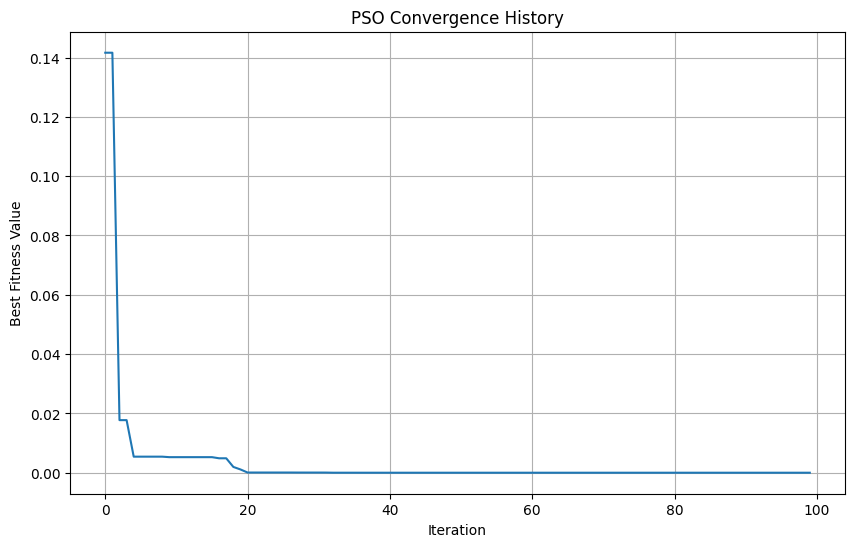


=== Rastrigin Function ===
Iteration 0: Best fitness = 6.129795
Iteration 20: Best fitness = 0.036590
Iteration 40: Best fitness = 0.001030
Iteration 60: Best fitness = 0.000023
Iteration 80: Best fitness = 0.000000
Best position: [-5.61861390e-06  2.53465241e-06]
Best fitness: 0.000000


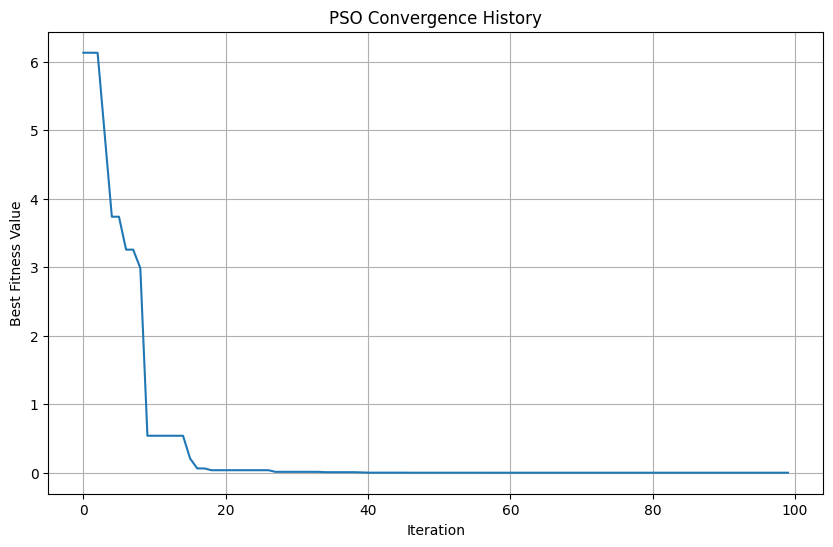

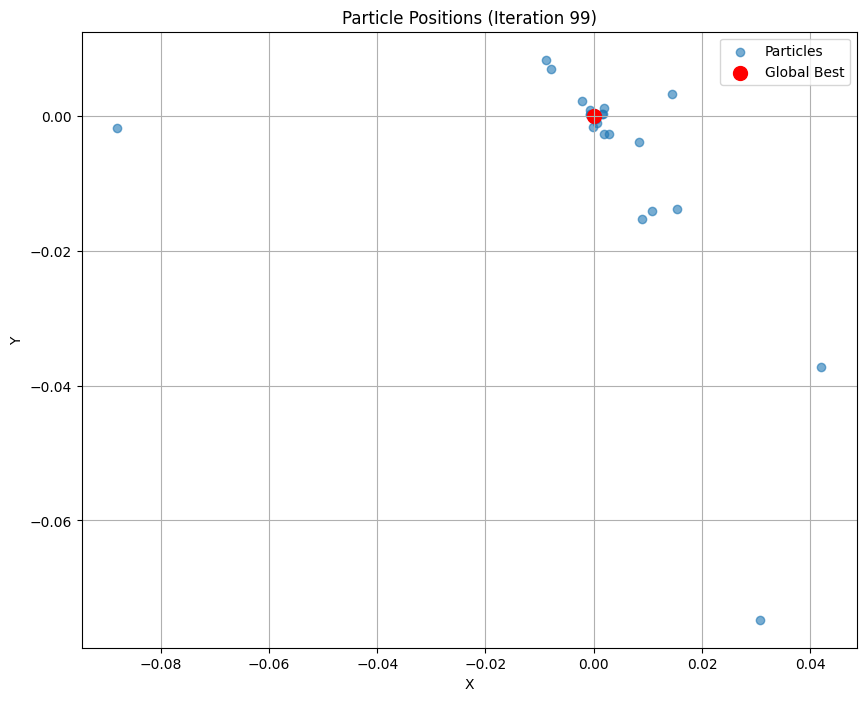

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class PSO(object):
  """
    Class implementing PSO algorithm.
  """
  def __init__(self, func, init_pos, n_particles, w=0.75, c1=1.5, c2=1.5, bounds=None):
    """
      Initialize the key variables.
      Args:
        func (function): the fitness function to optimize.
        init_pos (array-like): the initial position to kick off the
                               optimization process.
        n_particles (int): the number of particles of the swarm.
        w (float): inertia weight
        c1 (float): cognitive coefficient
        c2 (float): social coefficient
        bounds (tuple): (lower_bound, upper_bound) for each dimension
    """
    self.func = func
    self.n_particles = n_particles
    self.init_pos = np.array(init_pos)
    self.particle_dim = len(init_pos)
    self.w = w
    self.c1 = c1
    self.c2 = c2
    self.bounds = bounds
    
    # Initialize particle positions using a uniform distribution
    if bounds is not None:
        lower, upper = bounds
        self.particles_pos = np.random.uniform(lower, upper, size=(n_particles, self.particle_dim))
    else:
        self.particles_pos = np.random.uniform(size=(n_particles, self.particle_dim)) * self.init_pos
    
    # Initialize particle velocities using a uniform distribution
    self.velocities = np.random.uniform(-1, 1, size=(n_particles, self.particle_dim))

    # Initialize the best positions
    self.g_best = self.particles_pos[np.argmin([self.func(pos) for pos in self.particles_pos])]
    self.p_best = self.particles_pos.copy()
    
    # Store history for visualization
    self.history = []
    self.fitness_history = []

  def update_position(self, x, v):
    """
      Update particle position.
      Args:
        x (array-like): particle current position.
        v (array-like): particle current velocity.
      Returns:
        The updated position (array-like).
    """
    x = np.array(x)
    v = np.array(v)
    new_x = x + v
    
    # Apply bounds if specified
    if self.bounds is not None:
        lower, upper = self.bounds
        new_x = np.clip(new_x, lower, upper)
    
    return new_x

  def update_velocity(self, x, v, p_best, g_best):
    """
      Update particle velocity.
      Args:
        x (array-like): particle current position.
        v (array-like): particle current velocity.
        p_best (array-like): the best position found so far for a particle.
        g_best (array-like): the best position regarding
                             all the particles found so far.
      Returns:
        The updated velocity (array-like).
    """
    x = np.array(x)
    v = np.array(v)
    assert x.shape == v.shape, 'Position and velocity must have same shape'
    
    # Random coefficients
    r1 = np.random.uniform(0, 1)
    r2 = np.random.uniform(0, 1)
    
    p_best = np.array(p_best)
    g_best = np.array(g_best)

    new_v = self.w * v + self.c1 * r1 * (p_best - x) + self.c2 * r2 * (g_best - x)
    return new_v

  def optimize(self, maxiter=200, verbose=True):
    """
      Run the PSO optimization process until the stopping criteria is met.
      Case for minimization. The aim is to minimize the cost function.
      Args:
          maxiter (int): the maximum number of iterations before stopping
                         the optimization.
          verbose (bool): whether to print progress
      Returns:
          The best solution found (array-like).
    """
    for iteration in range(maxiter):
      for i in range(self.n_particles):
          x = self.particles_pos[i]
          v = self.velocities[i]
          p_best = self.p_best[i]
          
          self.velocities[i] = self.update_velocity(x, v, p_best, self.g_best)
          self.particles_pos[i] = self.update_position(x, self.velocities[i])
          
          # Update the best position for particle i
          if self.func(self.particles_pos[i]) < self.func(p_best):
              self.p_best[i] = self.particles_pos[i].copy()
          
          # Update the best position overall
          if self.func(self.particles_pos[i]) < self.func(self.g_best):
              self.g_best = self.particles_pos[i].copy()
      
      # Store history
      self.history.append(self.particles_pos.copy())
      self.fitness_history.append(self.func(self.g_best))
      
      if verbose and iteration % 20 == 0:
          print(f'Iteration {iteration}: Best fitness = {self.func(self.g_best):.6f}')
    
    return self.g_best, self.func(self.g_best)
  
  def plot_convergence(self):
    """Plot the convergence history."""
    plt.figure(figsize=(10, 6))
    plt.plot(self.fitness_history)
    plt.xlabel('Iteration')
    plt.ylabel('Best Fitness Value')
    plt.title('PSO Convergence History')
    plt.grid(True)
    plt.show()
  
  def plot_particles_2d(self, iteration=-1):
    """Plot particle positions in 2D."""
    if len(self.history) == 0:
        print("No history available. Run optimize() first.")
        return
    
    particles = self.history[iteration]
    
    plt.figure(figsize=(10, 8))
    plt.scatter(particles[:, 0], particles[:, 1], alpha=0.6, label='Particles')
    plt.scatter(self.g_best[0], self.g_best[1], color='red', s=100, label='Global Best')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Particle Positions (Iteration {len(self.history) + iteration if iteration < 0 else iteration})')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example of the sphere function
def sphere(x):
  """
    In 3D: f(x,y,z) = x² + y² + z²
  """
  return np.sum(np.square(x))

# Example of the Rastrigin function
def rastrigin(x):
  """
    Rastrigin function: f(x) = A*n + sum(x_i^2 - A*cos(2*pi*x_i))
    where A = 10 and n is the dimension
  """
  A = 10
  n = len(x)
  return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))

if __name__ == '__main__':
  # Test with sphere function
  print("=== Sphere Function ===")
  init_pos = [1, 1, 1]
  pso_sphere = PSO(func=sphere, init_pos=init_pos, n_particles=50, bounds=(-5, 5))
  res_sphere = pso_sphere.optimize(maxiter=100, verbose=True)
  print(f'Best position: {res_sphere[0]}')
  print(f'Best fitness: {res_sphere[1]:.6f}')
  pso_sphere.plot_convergence()
  
  # Test with Rastrigin function
  print("\n=== Rastrigin Function ===")
  init_pos_2d = [1, 1]
  pso_rastrigin = PSO(func=rastrigin, init_pos=init_pos_2d, n_particles=30, bounds=(-5.12, 5.12))
  res_rastrigin = pso_rastrigin.optimize(maxiter=100, verbose=True)
  print(f'Best position: {res_rastrigin[0]}')
  print(f'Best fitness: {res_rastrigin[1]:.6f}')
  pso_rastrigin.plot_convergence()
  pso_rastrigin.plot_particles_2d()

## Visualization and Analysis

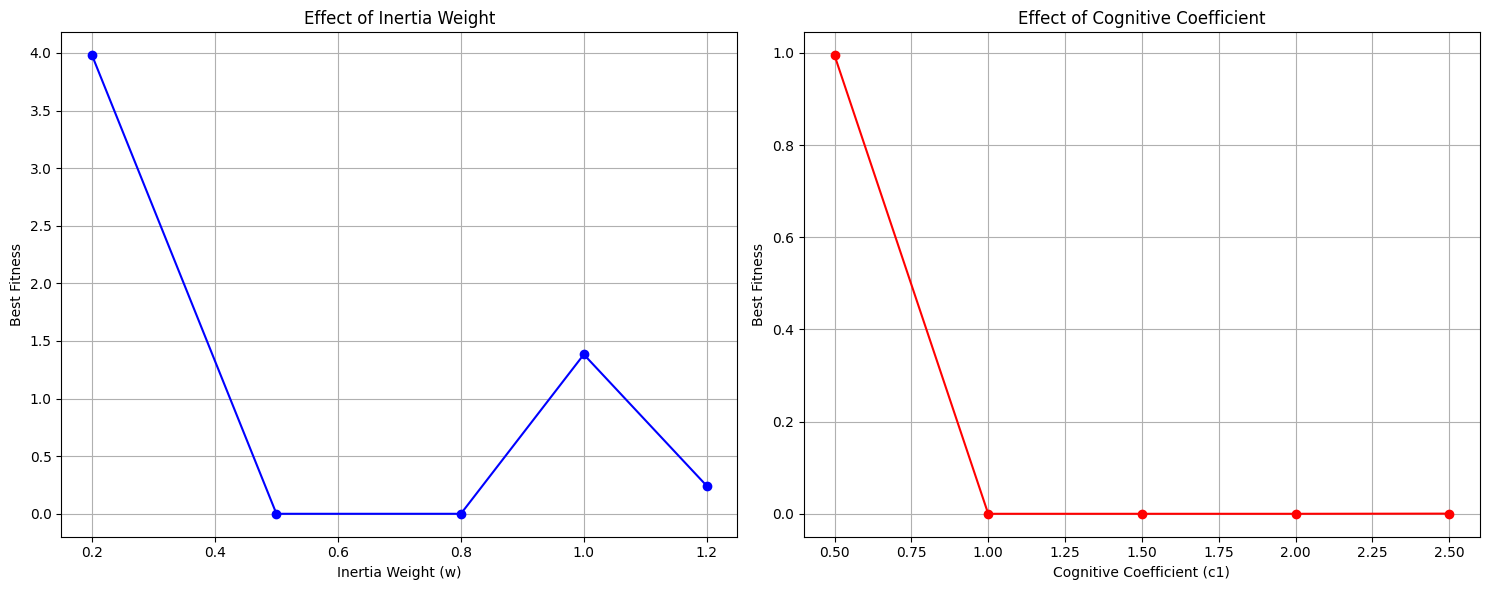

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def create_animation(pso_instance, save_path=None):
    """Create an animation of particle movement."""
    if len(pso_instance.history) == 0:
        print("No history available. Run optimize() first.")
        return
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    def animate(frame):
        ax.clear()
        particles = pso_instance.history[frame]
        
        # Plot particles
        ax.scatter(particles[:, 0], particles[:, 1], alpha=0.6, c='blue', s=50)
        
        # Plot global best
        ax.scatter(pso_instance.g_best[0], pso_instance.g_best[1], 
                  color='red', s=200, marker='*', label='Global Best')
        
        # Set limits based on bounds
        if pso_instance.bounds is not None:
            lower, upper = pso_instance.bounds
            ax.set_xlim(lower, upper)
            ax.set_ylim(lower, upper)
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(f'PSO Animation - Iteration {frame}')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    anim = FuncAnimation(fig, animate, frames=len(pso_instance.history), 
                        interval=100, repeat=True)
    
    if save_path:
        anim.save(save_path, writer='pillow')
    
    plt.show()
    return anim

# Parameter sensitivity analysis
def parameter_analysis():
    """Analyze the effect of different parameters on PSO performance."""
    test_function = rastrigin
    init_pos = [1, 1]
    n_particles = 30
    max_iter = 100
    
    # Test different inertia weights
    w_values = [0.2, 0.5, 0.8, 1.0, 1.2]
    w_results = []
    
    for w in w_values:
        pso = PSO(func=test_function, init_pos=init_pos, n_particles=n_particles, 
                 w=w, bounds=(-5.12, 5.12))
        best_pos, best_fitness = pso.optimize(maxiter=max_iter, verbose=False)
        w_results.append(best_fitness)
    
    # Test different cognitive coefficients
    c1_values = [0.5, 1.0, 1.5, 2.0, 2.5]
    c1_results = []
    
    for c1 in c1_values:
        pso = PSO(func=test_function, init_pos=init_pos, n_particles=n_particles, 
                 c1=c1, bounds=(-5.12, 5.12))
        best_pos, best_fitness = pso.optimize(maxiter=max_iter, verbose=False)
        c1_results.append(best_fitness)
    
    # Plot results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    ax1.plot(w_values, w_results, 'bo-')
    ax1.set_xlabel('Inertia Weight (w)')
    ax1.set_ylabel('Best Fitness')
    ax1.set_title('Effect of Inertia Weight')
    ax1.grid(True)
    
    ax2.plot(c1_values, c1_results, 'ro-')
    ax2.set_xlabel('Cognitive Coefficient (c1)')
    ax2.set_ylabel('Best Fitness')
    ax2.set_title('Effect of Cognitive Coefficient')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Run parameter analysis
parameter_analysis()